## Examen Practico - Tercer Parcial

#### 0) Cargar una de las imágenes histológicas

####  Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
#### Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
#### Visualizar la imagen

In [51]:
import numpy as np  # sirve para realizar calculos matemáticos de alto rendimiento y se asigna a np para que no se escriba completo 
from skimage import io # es una libreria estandar en python sirve para prosesar imágenes su funcion principal es transformar las imágenes en matrices numericas como png jpg
import matplotlib.pyplot as plt # es el encargado de generar graficos estadisticos y matematicos en python transforma numero o matrices o listas en representaciones visuales 
import cv2# sirve para cargar en python la libreria open cv es una herammienta muy importante en visualizacion artificial en procesamiento de imágenes o videos en forma real 
from skimage.measure import label, regionprops # sirve para detectar contar o medir objetos dentro de una imagen binaria a una imagen en blanco negro donde los objetos son blancos y el fondo es negro 
from scipy.ndimage import binary_fill_holes#sirve para rellenar automáticamente los huecos o agujeros negros que quedan dentro de los objetos blancos en una imagen binaria 


In [52]:
#lo que estamos haciendo es  buscar el archivo de la imagen llamado histo y lo guardamos en un a una nueva variable llamada imagen 
# con la funcion shape lo qu eetsamos haciendo es devolver una tupla con numeros de datos 
#el primer número que parese es la altura de la imagen en pixeles filas
# el segundo número es el ancho de pixeles de la imagen columnas
# el numero tres quiere decir que la imagen esta en color en un formato de rgb  # color rojo verde y azul rgb
imagen = io.imread('histo_2.jpg')
print(imagen.shape)


(1024, 1024, 3)


In [53]:
# lo que hice es tomar cada uno de los pixeles de la imagen y dividir entre 255.0
rgb = imagen / 255.0

imagen_normalizada = imagen / 255.0

print("Valor mínimo:", np.min(imagen_normalizada)) # Salida: 0.0#busca el pixel mas obscuro de toda la imagen al dar 0 esto dice que las zonas totalmente negras ahora valen céro 
print("Valor máximo:", np.max(imagen_normalizada)) # Salida: 1.0#busca el pixel mas brillante de toda la imagen esto nos dice que las zonas en blanco puro ahora valen uno 


Valor mínimo: 0.11372549019607843
Valor máximo: 1.0


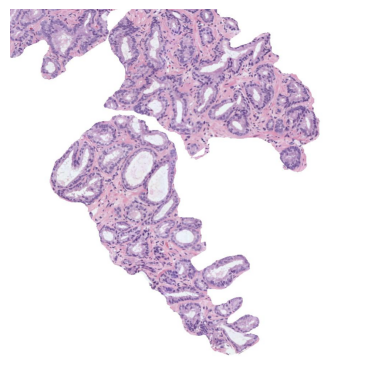

In [54]:
plt.imshow(imagen)
plt.axis('off')
plt.show()

#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

In [55]:
# Extraer la componente magenta de la imagen que corresponde a la región tisular
# Visualizar la imagen del canal magenta

In [56]:
with np.errstate(invalid='ignore', divide='ignore'):# este codigo le dice a python que si encuntra divisiones por céro o valores invalidos los ignore y continue 
    K = 1 - np.max(rgb, axis=2) #busca el valor máximo en los canales de rojo verde y azul y que se mueva atraves de la profundidad del color en el modelo cmy k representa la usencia de l aluz rflejada 
    C = (1 - rgb[:, :, 0] - K) / (1 - K) #cian,rojo
    M = (1 - rgb[:, :, 1] - K) / (1 - K) #magenta,verde
    Y = (1 - rgb[:, :, 2] - K) / (1 - K) # amarillo 
    #todos estos colores se restan en 1 y obtienen el color opuesto es decir extrae toda la capa del rojo y obtiene el color opuesto al cian
#Finalmente se dividen entre (1 - K) para estandarizar el contraste y remover la influencia del color negro en la mezcla.k=color negro

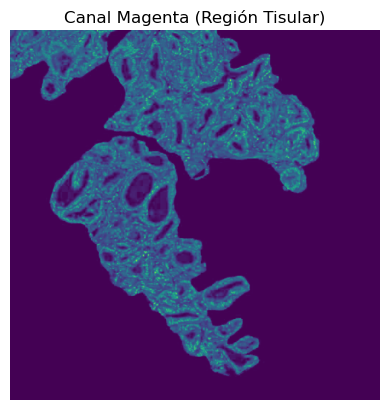

In [57]:
#extraemos la magenta extraida 
plt.imshow(M)
plt.title("Canal Magenta (Región Tisular)")
plt.axis('off')
plt.show()


#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

In [71]:
# Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1s y el resto de los píxeles tengan un valor de 0.
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
# Visualizar la máscara resultante

In [72]:
#  Convertimos a rango 0-255 en formato uint8 que se tranforma a números flotantes de son 8 bits usando la variable Magenta de arriba
M_uint8 = (M * 255).astype(np.uint8)
# astype su función es transformar el canal Magenta en números decimáles matemáticos a un formato de imagen estandar para que la computadora pueda guardarlo o procesarlo como un archivo visual

In [73]:
blur = cv2.GaussianBlur(M_uint8, (5, 5), 0)
# estamos reducciondo los cambios bruscos de la imagen para que se vea mas limpia 

In [74]:
# 3. Aplicamos el método de otsu invertido sobre la imagen filtrada blur
t, mask = cv2.threshold(blur, 0, 1, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
print("Valores únicos en la máscara:", np.unique(mask))
#estamos semegtando la imagen filtrada para separar objeto y fondo usando un umbral calculado por outsu invertimos el resultado para que el fondo sea blanco y el objeto negro 


Valores únicos en la máscara: [0 1]


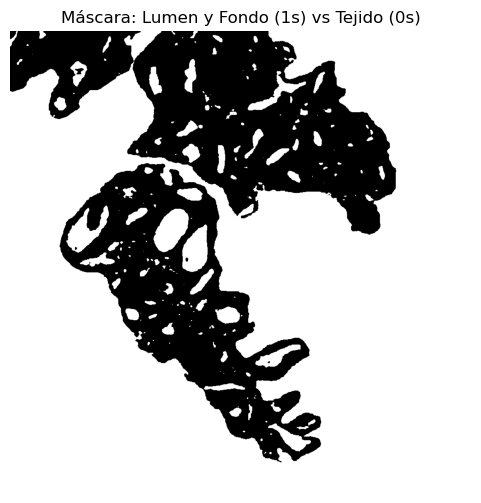

In [75]:
# 4. Visualizar la máscara resultante usando la variable 'mask'
plt.figure(figsize=(6, 6))
plt.imshow(mask, cmap='gray')
plt.title("Máscara: Lumen y Fondo (1s) vs Tejido (0s)")
plt.axis('off')
plt.show()

#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

In [76]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos cuya área sea menor a 300 píxeles
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
# Visualizaer la máscara resultante

In [77]:
from skimage.morphology import remove_small_objects
mask_bool = mask.astype(bool)
#convertimos la mascara a tipo booleano verdadero falso es un requisito obligatorio de skimage 

In [78]:
mask_limpia = remove_small_objects(mask_bool, min_size=300)
#eliminamos los objetos blancos  cuyo tamaño sea menor a 300 pixeles

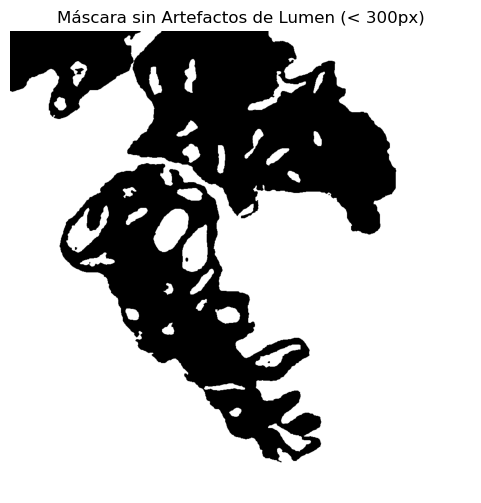

In [79]:
#visualizamos la mascara limpia 
plt.figure(figsize=(6, 6))
plt.imshow(mask_limpia, cmap='gray')
plt.title("Máscara sin Artefactos de Lumen (< 300px)")
plt.axis('off')
plt.show()


#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

In [80]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) de manera que únicamente los lúmenes sean blancos
# y el resto de la imagen negra. Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero
# se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.
# Visualizar la máscara resultante. 


#### tuve que cambiar de estrategia porque se me presento uninconveniente ya que esta imagen tiene demaciada textura anteriormente me dio un resultado pixelado poroso y lleno de puntos negros esto se debe a que en  ese intento  utilize el algoritmo de Crecimiento de Regiones (Region Growing) con un criterio de expansión muy estricto sobre una imagen con mucha textura.

In [85]:
img = cv2.imread('histo_2.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

valor_umbral = 200 
_, mascara_final = cv2.threshold(blurred, valor_umbral, 255, cv2.THRESH_BINARY)#todo pixel con mayor a 200 se vuelve blanco hasta 255 lo demas es negro

mascara_sin_fondo = mascara_final.copy()
h, w = mascara_sin_fondo.shape
mask_ff = np.zeros((h + 2, w + 2), np.uint8)

cv2.floodFill(mascara_sin_fondo, mask_ff, (0, 0), 0)
cv2.floodFill(mascara_sin_fondo, mask_ff, (w - 1, 0), 0)
cv2.floodFill(mascara_sin_fondo, mask_ff, (0, h - 1), 0)
cv2.floodFill(mascara_sin_fondo, mask_ff, (w - 1, h - 1), 0)
#v2.floodFillEs la herramienta de bote de pintura al aplicarla en las cuatro esquinas de la imagen 0,0,(w-1,0, pinta de color negro (0) todo lo que esté conectado al borde exterior Esto sirve para eliminar el fondo de la imagen o lúmenes cortados en los bordes dejando solo los objetos que están completamente adentro.

(0,
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(1024, 1024), dtype=uint8),
 array([[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]], shape=(1026, 1026), dtype=uint8),
 (0, 0, 0, 0))

In [86]:
#RETR_EXTERNAL asegura que solo detecte el contorno exterior de cada objeto ignorando de momento los agujeros internos.
contornos, _ = cv2.findContours(mascara_sin_fondo, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

#Ordenar los contornos de mayor a menor según su área exterior
contornos_ordenados = sorted(contornos, key=cv2.contourArea, reverse=True)

# Selecciona únicamente los dos más grandes
dos_contornos_grandes = contornos_ordenados[:2]
#ordena que se quede con los lumenes mas grandes 

In [87]:
# Crear una máscara que sirva de molde externo para aislar esos dos objetos
molde_seleccion = np.zeros_like(mascara_sin_fondo)
cv2.drawContours(molde_seleccion, dos_contornos_grandes, -1, 255, thickness=cv2.FILLED)
#np.zeros_like Crea una imagen completamente negra del mismo tamaño que la original.
#cv2.drawContours y thickness=cv2.FILLED Dibuja las dos siluetas grandes en la imagen negra y las rellena por completo de blanco. Esto actúa como una plantilla o máscara de recorte.
#solo se conserva lo que esté dentro del molde pero manteniendo el dibujo original
resultado_textura_original = cv2.bitwise_and(mascara_sin_fondo, mascara_sin_fondo, mask=molde_seleccion)
#cv2.bitwise_and Cruza la máscara original con el molde relleno al hacer esto vuelve a recuperar los detalles texturas y huecos negros internos que tenían originalmente esos dos lúmenes pero borrando absolutamente todo lo demás que estaba fuera de ellos


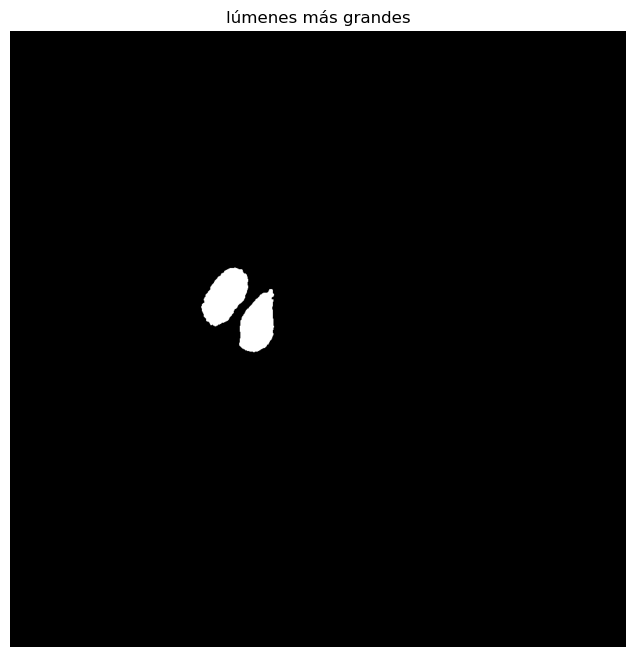

In [88]:
# 3. Mostrar el resultado con su estructura interna intacta
plt.figure(figsize=(8, 8))
plt.imshow(resultado_textura_original, cmap='gray')
plt.title("lúmenes más grandes")
plt.axis('off')
plt.show()
#Muestra la imagen final en la pantalla usando la paleta de colores de grises

##### lo que hicimos fue tomar una imagen histológica texturizada y realize una limpieza inteligente borramos el fondo eliminó el ruido descartó todos los objetos pequeños o irrelevantes y aisló exclusivamente los dos lúmenes más grandes lo valioso del algoritmo es que logró aislar estas dos estructuras por su tamaño exterior sin alterar ni rellenar sus detalles internos como núcleos, células o texturas interiores dejándolos listos para un análisis visual o médico preciso

#### 5) Rellenar los objetos de los lúmenes

In [89]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
# Visualizar la máscara resultante

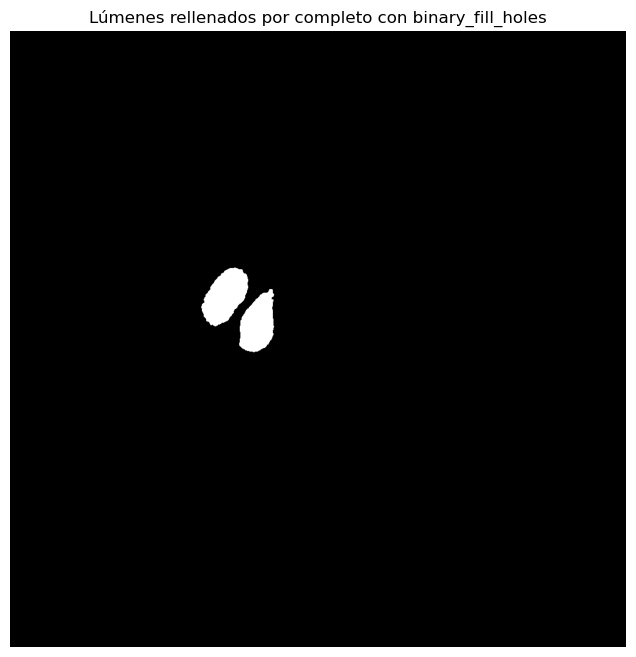

In [90]:
# --- NUEVA CELDA: RELLENAR LOS OBJETOS AISLADOS ---
from scipy.ndimage import binary_fill_holes
import numpy as np
import matplotlib.pyplot as plt

#  Converti la imagen de la celda anterior a tipo booleano verdadero o falso 
mask_bool = resultado_textura_original.astype(bool)

# Aplique la función binary_fill_holes para tapar los huecos negros internos
lumenes_rellenos_bool = binary_fill_holes(mask_bool)

# Volvi a convertir a formato de imagen normal (0 y 255)
lumenes_rellenos = lumenes_rellenos_bool.astype(np.uint8) * 255

#  resultado final relleno
plt.figure(figsize=(8, 8))
plt.imshow(lumenes_rellenos, cmap='gray')
plt.title("Lúmenes rellenados por completo con binary_fill_holes")
plt.axis('off')
plt.show()


#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

In [91]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios
# para que los contornos en verde sean perfectamente visibles. 
# Visualizar la imagen superpuesta


In [92]:
#Cree una copia de la imagen original para no arruinar la variable original
img_out = imagen.copy()

In [93]:
# la mascara deve estar limpia y en formato uint8 0 o 255
mask_uint8 = mask_limpia.astype(np.uint8) * 255
mask_uint8[0:5, :] = 0
mask_uint8[-5:, :] = 0
mask_uint8[:, 0:5] = 0
mask_uint8[:, -5:] = 0

In [94]:
# Detectamos todos los contornos externos de los lumenes
contornos, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

In [95]:
# Dibujamos los contornos en verde puro R=0, G=255, B=0 con grosor de 4 pixeles para que se vea mejor 
# Como la imagen esta en formato rgb el color se pasa como 0, 255, 0
cv2.drawContours(img_out, contornos, -1, (0, 255, 0), 4)

array([[[185, 159, 194],
        [188, 162, 197],
        [191, 164, 199],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[180, 154, 189],
        [185, 158, 193],
        [191, 164, 199],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[174, 148, 183],
        [178, 151, 186],
        [189, 162, 197],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

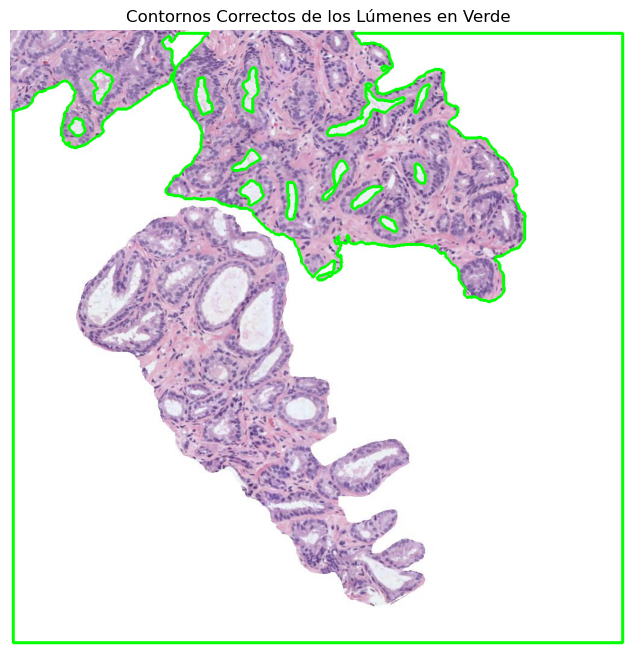

In [96]:
# 5. Visualizamos la imagen con la superposición corregida
plt.figure(figsize=(8, 8))
plt.imshow(img_out)
plt.title("Contornos Correctos de los Lúmenes en Verde")
plt.axis('off')

#### 7) Identificar y cropear el lumen más grande

In [97]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.
# Visualizar el lumen cropeado.

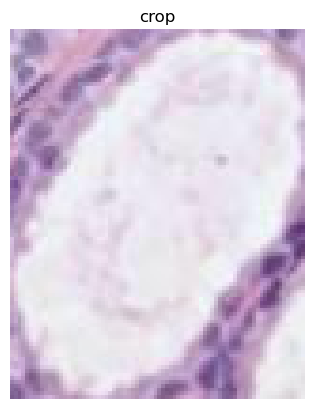

In [98]:
# esta es nuestra imagen original en rgb 
imagen = io.imread('histo_2.jpg')

lumenes_etiquetados = label(lumenes_rellenos)# esta funcion lo que hace es asignar un unico numero a una region conectada para poder indentificarlso 
propiedades = regionprops(lumenes_etiquetados)# ordena la region por area 
propiedades_ordenadas = sorted(propiedades, key=lambda x: x.area, reverse=True)# selecionar la region mas grande 
lumen_mayor = propiedades_ordenadas[0]# en esta funcion toma la region mas grande 

min_y, min_x, max_y, max_x = lumen_mayor.bbox# en este codigo recolectamos la imagen original 
new_img = imagen[min_y:max_y, min_x:max_x]# en este codigo mostramos la imagen recortada 

figs, ax = plt.subplots()
ax.imshow(new_img)
ax.set_title('crop')
ax.axis('off') 
plt.show()
 #localiza el lumen mas grande y lo recorta

#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado 

In [99]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.
# 1) Área
# 2) Área de la bounding box
# 3) Área convexa
# 4) Exentricidad
# 5) Diámetro equivalente
# 6) Extensión
# 7) Diámetro Feret
# 8) Longitud del eje mayor
# 9) Longitud del eje menor
# 10) Orientación
# 11) Perímetro
# 12) Solidez
# 13) Compacidad

In [100]:
# 1Área
print(f"1) Área: {lumen_mayor.area:.4f}")


1) Área: 4855.0000


In [101]:
# 2Área de la bounding box
print(f"2) Área de la bounding box: {lumen_mayor.area_bbox:.4f}")


2) Área de la bounding box: 7644.0000


In [102]:
# 3Área convexa
print(f"3) Área convexa: {lumen_mayor.area_convex:.4f}")


3) Área convexa: 5040.0000


In [103]:
# 4Excentricidad
print(f"4) Excentricidad: {lumen_mayor.eccentricity:.4f}")


4) Excentricidad: 0.8357


In [104]:
# 5Diámetro equivalente
print(f"5) Diámetro equivalente: {lumen_mayor.equivalent_diameter:.4f}")
#equivalent_diameter_area  la proxima version de la libreria 

5) Diámetro equivalente: 78.6230


In [105]:
# 6Extensión
print(f"6) Extensión: {lumen_mayor.extent:.4f}")


6) Extensión: 0.6351


In [106]:
# 7Diámetro Feret
import numpy as np
try:
    diametro_feret = lumen_mayor.feret_diameter_max
except AttributeError:
    min_y, min_x, max_y, max_x = lumen_mayor.bbox
    diametro_feret = np.sqrt((max_y - min_y)**2 + (max_x - min_x)**2)

print(f"7) Diámetro Feret: {diametro_feret:.4f}")


7) Diámetro Feret: 106.5505


In [107]:
# 8Longitud del eje mayor
print(f"8) Longitud del eje mayor: {lumen_mayor.axis_major_length:.4f}")


8) Longitud del eje mayor: 106.3642


In [108]:
# 9Longitud del eje menor
print(f"9) Longitud del eje menor: {lumen_mayor.axis_minor_length:.4f}")


9) Longitud del eje menor: 58.4094


In [109]:
# 10Orientación
print(f"10) Orientación: {lumen_mayor.orientation:.4f}")


10) Orientación: -0.5622


In [110]:
# 11Perímetro
print(f"11) Perímetro: {lumen_mayor.perimeter:.4f}")


11) Perímetro: 288.3919


In [111]:
# 12Solidez
print(f"12) Solidez: {lumen_mayor.solidity:.4f}")


12) Solidez: 0.9633


In [112]:
# 13Compacidad
import numpy as np
compacidad = (lumen_mayor.perimeter ** 2) / (4 * np.pi * lumen_mayor.area)
print(f"13) Compacidad: {compacidad:.4f}")


13) Compacidad: 1.3632
